# Brain Tumor Detection using EfficientNetB0
This notebook trains a deep learning model for MRI brain tumor classification.

Pipeline:
1. Import libraries
2. Load dataset
3. Build EfficientNet model
4. Train model
5. Evaluate model
6. Generate metrics & plots
7. ROC Curve
8. Grad-CAM visualization
9. Save model
10. Predict new MRI image


In [1]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

In [2]:
# Directories for training and testing data
train_dir  = r"D:\internhip pro\data\Training"
test_dir   = r"D:\internhip pro\data\Testing"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

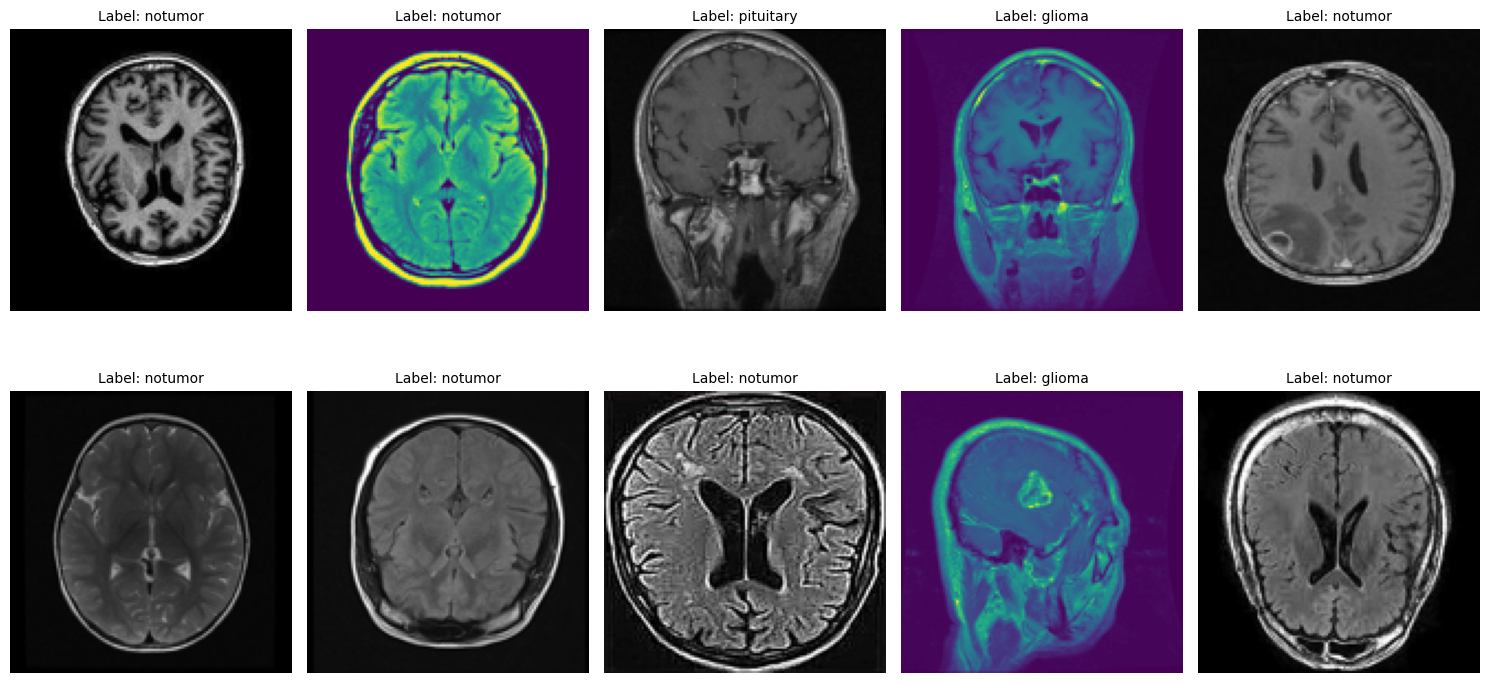

In [3]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
IMAGE_SIZE = 128 
# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


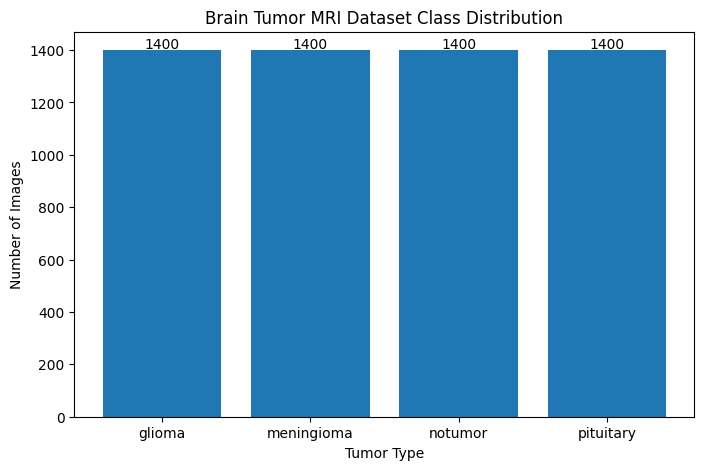

In [1]:
import os
import matplotlib.pyplot as plt

data_dir = r"D:\internhip pro\data\Training"

classes = []
counts = []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        classes.append(folder)
        counts.append(num_images)

plt.figure(figsize=(8,5))

bars = plt.bar(classes, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5,
             str(height), ha='center')

plt.title("Brain Tumor MRI Dataset Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")

plt.show()

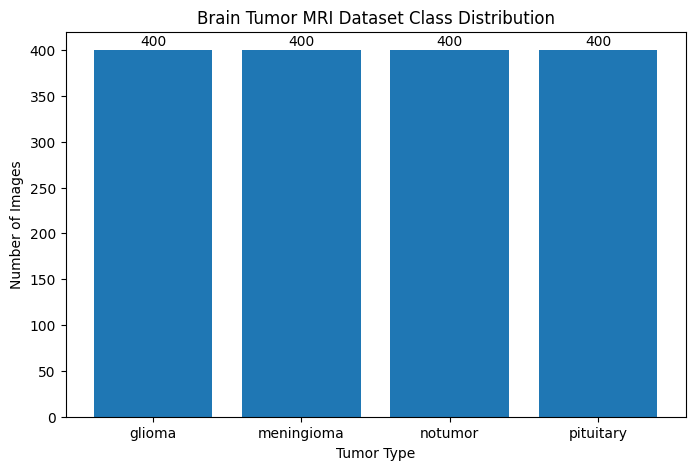

In [2]:
import os
import matplotlib.pyplot as plt

data_dir = r"D:\internhip pro\data\Testing"

classes = []
counts = []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        classes.append(folder)
        counts.append(num_images)

plt.figure(figsize=(8,5))

bars = plt.bar(classes, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5,
             str(height), ha='center')

plt.title("Brain Tumor MRI Dataset Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")

plt.show()

In [4]:
# Image Augmentation function
def augment_image(image):
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE), color_mode="rgb")
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = sorted(os.listdir(train_dir))    
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [5]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - loss: 0.4622 - sparse_categorical_accuracy: 0.8204
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - loss: 0.2348 - sparse_categorical_accuracy: 0.9116
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - loss: 0.1598 - sparse_categorical_accuracy: 0.9421
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 277s 991ms/step - loss: 0.1058 - sparse_categorical_accuracy: 0.9609
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 273s 976ms/step - loss: 0.0863 - sparse_categorical_accuracy: 0.9659


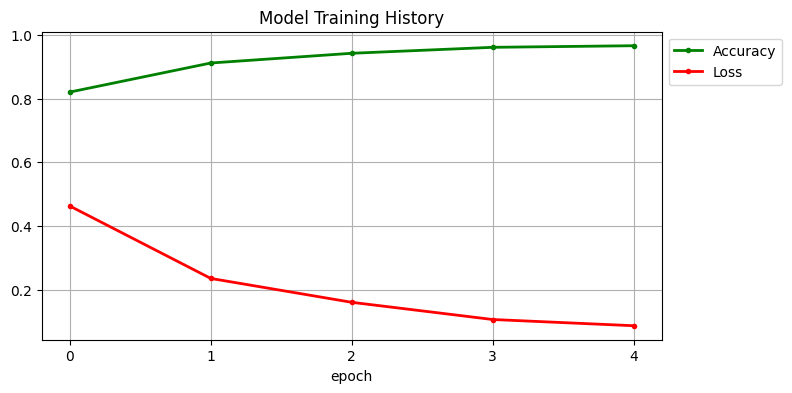

In [6]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()



In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

def load_test_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE), color_mode="rgb")
        image = np.array(image) / 255.0
        images.append(image)
    return np.array(images)

# 1. Prediction on test data
test_images = load_test_images(test_paths)
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       400
           1       0.84      0.95      0.89       400
           2       0.95      1.00      0.97       400
           3       0.98      0.96      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



Confusion Matrix:
[[307  69  21   3]
 [ 16 380   0   4]
 [  0   0 400   0]
 [  6   6   2 386]]


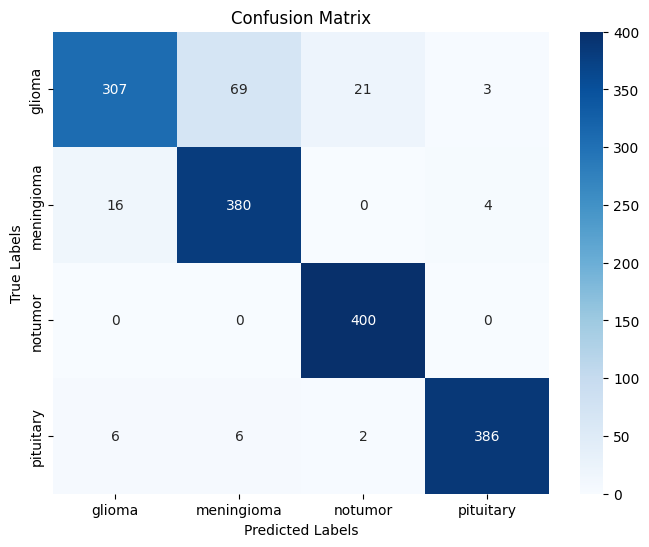

In [8]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

Confusion Matrix:
[[307  69  21   3]
 [ 16 380   0   4]
 [  0   0 400   0]
 [  6   6   2 386]]


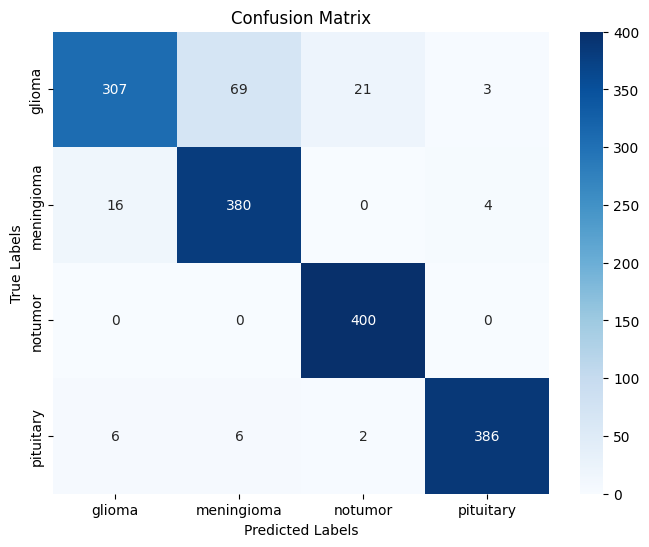

In [9]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

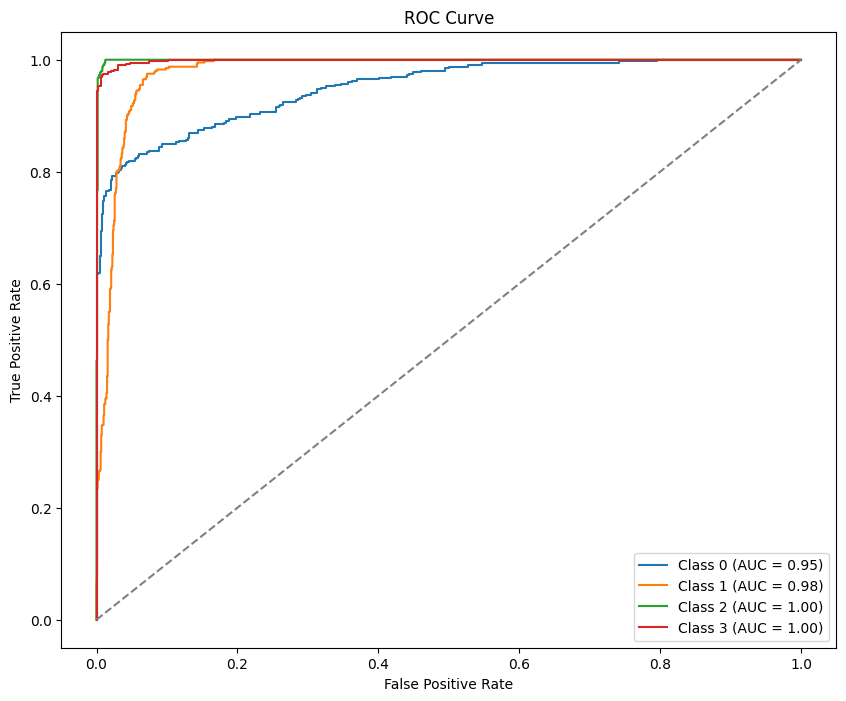

In [10]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(sorted(os.listdir(train_dir)))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [11]:
# Save the entire model
model.save('model_vg_128.h5')

In [13]:
model.save('model_vg1_128.keras')

In [14]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model_vg_128.h5', compile=False)

In [15]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model_vg1_128.keras', compile=False)

In [16]:
from sklearn.metrics import accuracy_score
import numpy as np

test_images = load_test_images(test_paths)

test_labels_encoded = encode_label(test_labels)

predictions = model.predict(test_images)

predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(test_labels_encoded, predicted_classes)

print("Test Accuracy:", accuracy*100,"%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step
Test Accuracy: 92.0625 %


In [17]:
from sklearn.metrics import accuracy_score
import numpy as np

# Load test images (without augmentation)
def load_test_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(128,128))
        img = np.array(img) / 255.0
        images.append(img)
    return np.array(images)

# Load test data
test_images = load_test_images(test_paths)

# Encode labels
test_labels_encoded = encode_label(test_labels)

# Predict
predictions = model.predict(test_images)

# Convert probabilities → class index
predicted_classes = np.argmax(predictions, axis=1)

# Accuracy
accuracy = accuracy_score(test_labels_encoded, predicted_classes)

print("Test Accuracy:", accuracy*100, "%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step
Test Accuracy: 92.0625 %


In [18]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = sorted(os.listdir(train_dir))
def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        image = load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE), color_mode="rgb")        
        img_array = img_to_array(image) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step


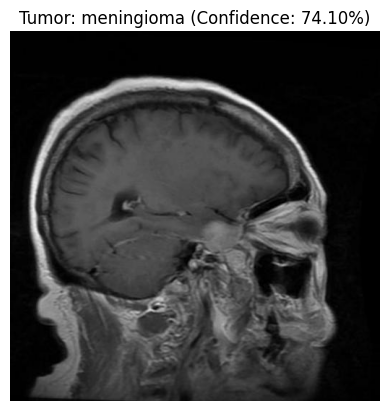

In [19]:
# Example usage
image_path = r"D:\internhip pro\data\Tr-aug-me_15.jpg"  # Provide the path to your new image
detect_and_display(image_path, model)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


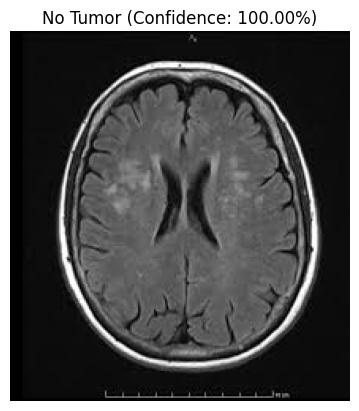

In [48]:


image_path = r"D:\internhip pro\29 no.jpg"  # Provide the path to your new image
detect_and_display(image_path, model)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


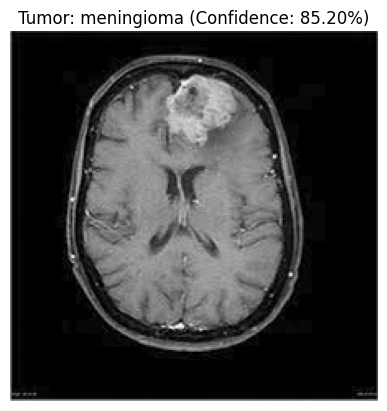

In [20]:

# Example usage
image_path = r"D:\internhip pro\image.png"  # Provide the path to your new image
detect_and_display(image_path, model)
        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


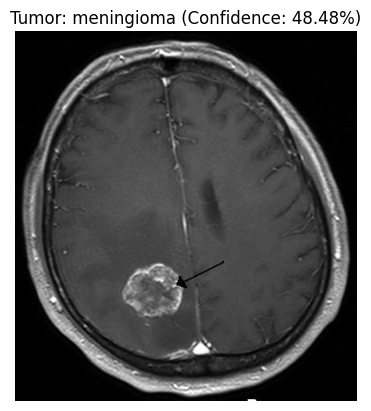

: 

In [ ]:
image_path = r"D:\internhip pro\Hirnmetastase_MRT-T1_KM.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


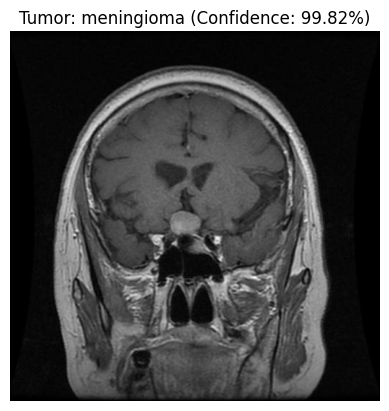

In [22]:
image_path = r"data/Testing/pituitary/Te-pi_1.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


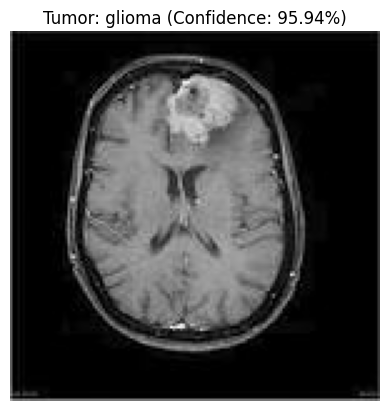

In [ ]:

# Example usage
image_path = r"D:\internhip pro\download.jpeg"  

# Provide the path to your new image
detect_and_display(image_path, model)